In [1]:

# imports and load
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')

# Load the ML-ready dataset from Week 1
df = pd.read_csv('data/processed/telco_churn_features.csv')

print(f"Dataset loaded: {df.shape}")
print(f"Churn rate    : {df['Churn'].mean()*100:.1f}%")
print(f"\nAll columns:")
for col in df.columns:
    print(f"  {col}: {df[col].dtype}")

Dataset loaded: (7043, 24)
Churn rate    : 26.5%

All columns:
  gender: int64
  SeniorCitizen: int64
  Partner: int64
  Dependents: int64
  tenure: int64
  PhoneService: int64
  MultipleLines: int64
  InternetService: str
  OnlineSecurity: int64
  OnlineBackup: int64
  DeviceProtection: int64
  TechSupport: int64
  StreamingTV: int64
  StreamingMovies: int64
  Contract: str
  PaperlessBilling: int64
  PaymentMethod: str
  MonthlyCharges: float64
  TotalCharges: float64
  Churn: int64
  numServices: int64
  chargePerMonth: float64
  tenureBucket: str
  contractRisk: int64


In [2]:
# separate features (X) and target (y)

# Drop target column to get features
X = df.drop(columns=['Churn'])
y = df['Churn']

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"\nTarget distribution:")
print(f"  Not churned (0): {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")
print(f"  Churned     (1): {(y==1).sum()} ({(y==1).mean()*100:.1f}%)")

Features shape : (7043, 23)
Target shape   : (7043,)

Target distribution:
  Not churned (0): 5174 (73.5%)
  Churned     (1): 1869 (26.5%)


In [3]:
#  identify which columns need which preprocessing

# Numerical columns — need StandardScaler
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges',
                  'numServices', 'chargePerMonth', 'contractRisk']

# Categorical columns — need OneHotEncoder
categorical_cols = ['InternetService', 'Contract',
                    'PaymentMethod', 'tenureBucket']

# Binary columns — already 0/1, no preprocessing needed
binary_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
               'PhoneService', 'MultipleLines', 'OnlineSecurity',
               'OnlineBackup', 'DeviceProtection', 'TechSupport',
               'StreamingTV', 'StreamingMovies', 'PaperlessBilling']

print("Numerical cols  (StandardScaler)  :", numerical_cols)
print("\nCategorical cols (OneHotEncoder)  :", categorical_cols)
print("\nBinary cols      (passthrough)    :", binary_cols)

# Verify all columns are accounted for
all_cols = numerical_cols + categorical_cols + binary_cols
missing = [c for c in X.columns if c not in all_cols]
print(f"\nUnaccounted columns: {missing}")
print("(Should be empty list [])")

Numerical cols  (StandardScaler)  : ['tenure', 'MonthlyCharges', 'TotalCharges', 'numServices', 'chargePerMonth', 'contractRisk']

Categorical cols (OneHotEncoder)  : ['InternetService', 'Contract', 'PaymentMethod', 'tenureBucket']

Binary cols      (passthrough)    : ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling']

Unaccounted columns: []
(Should be empty list [])


In [4]:
#  split data 80/20 with stratification
# stratify=y ensures both splits have same churn rate (26.5%)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          
)

print("Train/Test Split Results:")
print(f"{'':20} {'Count':>8} {'Churn Rate':>12}")
print("-" * 42)
print(f"{'Training set':20} {len(X_train):>8} {y_train.mean()*100:>11.1f}%")
print(f"{'Test set':20} {len(X_test):>8}  {y_test.mean()*100:>11.1f}%")
print(f"{'Full dataset':20} {len(X):>8}  {y.mean()*100:>11.1f}%")
print("-" * 42)
print("\nChurn rates are equal in both splits — stratification worked!")

Train/Test Split Results:
                        Count   Churn Rate
------------------------------------------
Training set             5634        26.5%
Test set                 1409         26.5%
Full dataset             7043         26.5%
------------------------------------------

Churn rates are equal in both splits — stratification worked!


In [5]:
#  build sklearn ColumnTransformer
# This applies different preprocessing to different column types

# StandardScaler: normalises numerical cols to mean=0, std=1
# OneHotEncoder : converts text categories to binary columns
# passthrough    : binary cols passed as-is (already 0/1)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore',
                              sparse_output=False), categorical_cols),
        ('bin', 'passthrough', binary_cols)
    ]
)

print("Preprocessor built successfully!")
print("\nWhat it does:")
print("  StandardScaler  → normalises tenure, charges, numServices")
print("  OneHotEncoder   → expands InternetService, Contract, PaymentMethod, tenureBucket")
print("  passthrough     → keeps binary 0/1 columns unchanged")

Preprocessor built successfully!

What it does:
  StandardScaler  → normalises tenure, charges, numServices
  OneHotEncoder   → expands InternetService, Contract, PaymentMethod, tenureBucket
  passthrough     → keeps binary 0/1 columns unchanged


In [6]:
#  fit on training data only, transform both splits
# IMPORTANT: fit ONLY on X_train — never on X_test
# This prevents data leakage

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)   # only transform, not fit

print(f"X_train shape before preprocessing: {X_train.shape}")
print(f"X_train shape after preprocessing : {X_train_proc.shape}")
print(f"\nX_test shape before preprocessing : {X_test.shape}")
print(f"X_test shape after preprocessing  : {X_test_proc.shape}")
print(f"\nExtra columns added by OneHotEncoder:")
print(f"  {X_train_proc.shape[1] - X_train.shape[1]} new columns created")

X_train shape before preprocessing: (5634, 23)
X_train shape after preprocessing : (5634, 33)

X_test shape before preprocessing : (1409, 23)
X_test shape after preprocessing  : (1409, 33)

Extra columns added by OneHotEncoder:
  10 new columns created


In [7]:
#  get all feature names after preprocessing
# Useful for SHAP plots in Week 2 Day 5+

num_feature_names = numerical_cols
cat_feature_names = preprocessor.named_transformers_['cat']\
                                 .get_feature_names_out(categorical_cols).tolist()
bin_feature_names = binary_cols

all_feature_names = num_feature_names + cat_feature_names + bin_feature_names

print(f"Total features after preprocessing: {len(all_feature_names)}")
print("\nAll feature names:")
for i, name in enumerate(all_feature_names):
    print(f"  {i+1:2}. {name}")

Total features after preprocessing: 33

All feature names:
   1. tenure
   2. MonthlyCharges
   3. TotalCharges
   4. numServices
   5. chargePerMonth
   6. contractRisk
   7. InternetService_DSL
   8. InternetService_Fiber optic
   9. InternetService_No
  10. Contract_Month-to-month
  11. Contract_One year
  12. Contract_Two year
  13. PaymentMethod_Bank transfer (automatic)
  14. PaymentMethod_Credit card (automatic)
  15. PaymentMethod_Electronic check
  16. PaymentMethod_Mailed check
  17. tenureBucket_Growing
  18. tenureBucket_Loyal
  19. tenureBucket_Mature
  20. tenureBucket_New
  21. gender
  22. SeniorCitizen
  23. Partner
  24. Dependents
  25. PhoneService
  26. MultipleLines
  27. OnlineSecurity
  28. OnlineBackup
  29. DeviceProtection
  30. TechSupport
  31. StreamingTV
  32. StreamingMovies
  33. PaperlessBilling


In [9]:
# save everything needed for model training tomorrow
import joblib
import os

os.makedirs('models', exist_ok=True)

# Save preprocessor
joblib.dump(preprocessor, 'models/preprocessor.pkl')
print("Saved: models/preprocessor.pkl")

# Save processed arrays
np.save('models/X_train_proc.npy', X_train_proc)
np.save('models/X_test_proc.npy',  X_test_proc)
np.save('models/y_train.npy',      y_train.values)
np.save('models/y_test.npy',       y_test.values)
print("Saved: models/X_train_proc.npy")
print("Saved: models/X_test_proc.npy")
print("Saved: models/y_train.npy")
print("Saved: models/y_test.npy")

# Save feature names
import json
with open('models/feature_names.json', 'w') as f:
    json.dump(all_feature_names, f)
print("Saved: models/feature_names.json")

print("\nAll splits and preprocessor saved!")

Saved: models/preprocessor.pkl
Saved: models/X_train_proc.npy
Saved: models/X_test_proc.npy
Saved: models/y_train.npy
Saved: models/y_test.npy
Saved: models/feature_names.json

All splits and preprocessor saved!


In [12]:
# — day notes
notes = """
# Week 2 Day 1 — Train/Test Split + Preprocessing Pipeline

## What was done today

### Train/Test Split
- Split ratio : 80% train / 20% test
- Train size  : 5,634 customers
- Test size   : 1,409 customers
- stratify=y  : ensures equal churn rate in both splits (26.5%)
- random_state: 42 (reproducible results every run)

### Why stratify?
Without stratify, random chance could put more churners in train
than test, making evaluation unreliable. Stratification guarantees
the 26.5% churn rate is preserved in both splits.

### Preprocessing Pipeline (ColumnTransformer)
| Transformer    | Columns              | Why |
|----------------|----------------------|-----|
| StandardScaler | numerical (6 cols)   | XGBoost works better with normalised features |
| OneHotEncoder  | categorical (4 cols) | ML models need numbers not text |
| passthrough    | binary (13 cols)     | Already 0/1, no change needed |

### Data Leakage Prevention
- preprocessor.fit_transform() called ONLY on X_train
- preprocessor.transform() called on X_test (no fitting)
- This prevents test data statistics leaking into training

### Shape after preprocessing
- Before : 23 columns
- After  : 33 columns (OneHotEncoder added 10 binary columns)

## Files Saved
- models/preprocessor.pkl     ← reusable preprocessor
- models/X_train_proc.npy     ← processed training features
- models/X_test_proc.npy      ← processed test features
- models/y_train.npy          ← training labels
- models/y_test.npy           ← test labels
- models/feature_names.json   ← feature names for SHAP

## Tomorrow — Week 2 Day 2
- Train Logistic Regression as baseline model
- Evaluate: accuracy, F1, ROC-AUC, confusion matrix
- This gives us a benchmark to beat with XGBoost
"""

with open('reports/week2_notes.md', 'w' , encoding="utf-8") as f:
    f.write(notes)

print("Notes saved!")
print("\nWeek 2 Day 1 complete!")

Notes saved!

Week 2 Day 1 complete!


In [1]:
#  reload everything
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              confusion_matrix, classification_report,
                              roc_curve, precision_recall_curve)

plt.style.use('seaborn-v0_8')

# Load saved splits from yesterday
X_train_proc = np.load('models/X_train_proc.npy')
X_test_proc  = np.load('models/X_test_proc.npy')
y_train      = np.load('models/y_train.npy')
y_test       = np.load('models/y_test.npy')

with open('models/feature_names.json') as f:
    feature_names = json.load(f)

print(f"Train shape : {X_train_proc.shape}")
print(f"Test shape  : {X_test_proc.shape}")
print(f"Features    : {len(feature_names)}")
print("\nAll data loaded successfully!")

Train shape : (5634, 33)
Test shape  : (1409, 33)
Features    : 33

All data loaded successfully!


In [2]:
#  train logistic regression baseline
# This is our benchmark — XGBoost must beat these numbers

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,        # enough iterations to converge
    class_weight='balanced'  # handles class imbalance automatically
)

lr_model.fit(X_train_proc, y_train)
print("Logistic Regression trained!")

# Make predictions
y_pred_lr      = lr_model.predict(X_test_proc)
y_pred_lr_prob = lr_model.predict_proba(X_test_proc)[:, 1]

print(f"\nSample predictions (first 10):")
print(f"  Actual   : {y_test[:10].tolist()}")
print(f"  Predicted: {y_pred_lr[:10].tolist()}")
print(f"  Prob     : {[round(p,2) for p in y_pred_lr_prob[:10]]}")

Logistic Regression trained!

Sample predictions (first 10):
  Actual   : [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
  Predicted: [0, 1, 0, 1, 0, 1, 1, 0, 0, 1]
  Prob     : [np.float64(0.11), np.float64(0.82), np.float64(0.14), np.float64(0.56), np.float64(0.07), np.float64(0.79), np.float64(0.67), np.float64(0.29), np.float64(0.01), np.float64(0.55)]


In [3]:
# calculate all evaluation metrics

acc    = accuracy_score(y_test, y_pred_lr)
f1     = f1_score(y_test, y_pred_lr)
roc    = roc_auc_score(y_test, y_pred_lr_prob)
f1_w   = f1_score(y_test, y_pred_lr, average='weighted')

print("="*45)
print("  LOGISTIC REGRESSION — RESULTS")
print("="*45)
print(f"  Accuracy        : {acc*100:.2f}%")
print(f"  F1 Score(churn) : {f1:.4f}")
print(f"  F1 Weighted     : {f1_w:.4f}")
print(f"  ROC-AUC         : {roc:.4f}")
print("="*45)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr,
                             target_names=['Retained', 'Churned']))

  LOGISTIC REGRESSION — RESULTS
  Accuracy        : 73.95%
  F1 Score(churn) : 0.6157
  F1 Weighted     : 0.7533
  ROC-AUC         : 0.8458

Classification Report:
              precision    recall  f1-score   support

    Retained       0.90      0.72      0.80      1035
     Churned       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



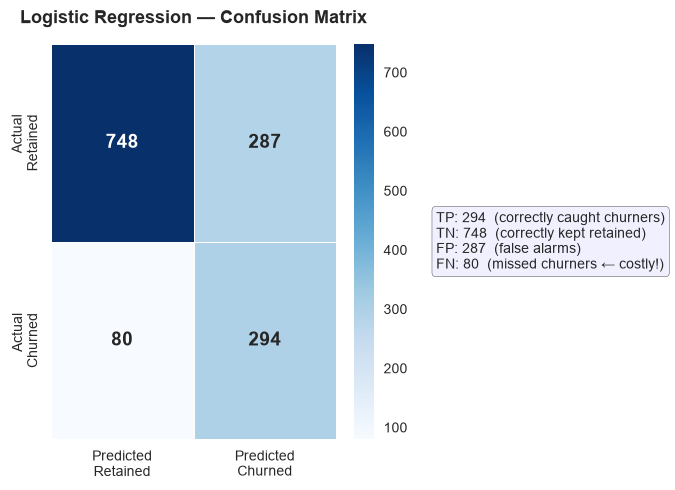

True Positives  (caught churners)  : 294
False Negatives (missed churners)  : 80  ← these cost money!
False Positives (false alarms)     : 287
True Negatives  (correct retained) : 748


In [4]:
#  confusion matrix visualization
cm = confusion_matrix(y_test, y_pred_lr)

fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted\nRetained', 'Predicted\nChurned'],
            yticklabels=['Actual\nRetained', 'Actual\nChurned'],
            linewidths=0.5, ax=ax,
            annot_kws={'size': 14, 'weight': 'bold'})

ax.set_title('Logistic Regression — Confusion Matrix',
             fontweight='bold', fontsize=13, pad=15)

# Add metric annotations
tn, fp, fn, tp = cm.ravel()
ax.text(1.35, 0.5,
        f"TP: {tp}  (correctly caught churners)\n"
        f"TN: {tn}  (correctly kept retained)\n"
        f"FP: {fp}  (false alarms)\n"
        f"FN: {fn}  (missed churners ← costly!)",
        transform=ax.transAxes,
        fontsize=10, verticalalignment='center',
        bbox=dict(boxstyle='round', facecolor='#EEEDFE', alpha=0.8))

plt.tight_layout()
plt.savefig('reports/lr_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"True Positives  (caught churners)  : {tp}")
print(f"False Negatives (missed churners)  : {fn}  ← these cost money!")
print(f"False Positives (false alarms)     : {fp}")
print(f"True Negatives  (correct retained) : {tn}")

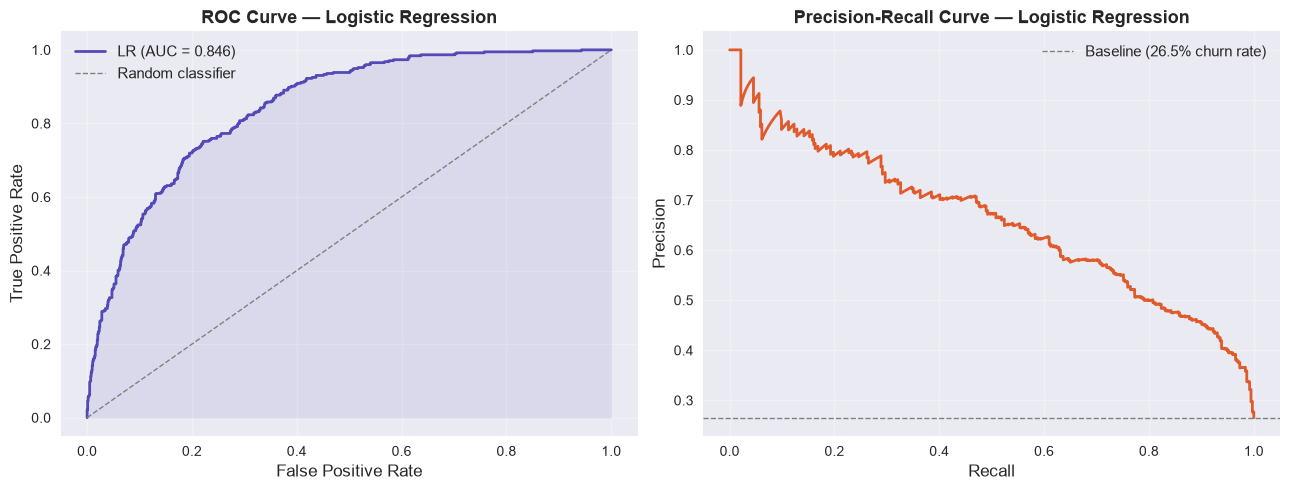

In [5]:
#  ROC curve
# Shows model performance across all classification thresholds

fpr, tpr, thresholds = roc_curve(y_test, y_pred_lr_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curve
axes[0].plot(fpr, tpr, color='#534AB7', linewidth=2,
             label=f'LR (AUC = {roc:.3f})')
axes[0].plot([0,1], [0,1], color='gray', linestyle='--',
             linewidth=1, label='Random classifier')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#534AB7')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve — Logistic Regression',
                   fontweight='bold', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_lr_prob)
axes[1].plot(recall, precision, color='#E05A2B', linewidth=2)
axes[1].axhline(y=y_test.mean(), color='gray', linestyle='--',
                linewidth=1, label='Baseline (26.5% churn rate)')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve — Logistic Regression',
                   fontweight='bold', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('reports/lr_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# create a results tracker
# We'll add XGBoost results here tomorrow for comparison

results = {
    'Model'      : ['Logistic Regression'],
    'Accuracy'   : [round(acc*100, 2)],
    'F1_Churn'   : [round(f1, 4)],
    'F1_Weighted': [round(f1_w, 4)],
    'ROC_AUC'    : [round(roc, 4)],
    'TP'         : [int(tp)],
    'FN'         : [int(fn)],
    'FP'         : [int(fp)],
    'TN'         : [int(tn)]
}

results_df = pd.DataFrame(results)
results_df.to_csv('reports/model_results.csv', index=False)

print("Results logged to reports/model_results.csv")
print("\nCurrent leaderboard:")
print(results_df.to_string(index=False))

Results logged to reports/model_results.csv

Current leaderboard:
              Model  Accuracy  F1_Churn  F1_Weighted  ROC_AUC  TP  FN  FP  TN
Logistic Regression     73.95    0.6157       0.7533   0.8458 294  80 287 748


In [7]:
# save logistic regression model
joblib.dump(lr_model, 'models/lr_baseline.pkl')
print("Saved: models/lr_baseline.pkl")

# Quick sanity check — reload and predict one customer
lr_check = joblib.load('models/lr_baseline.pkl')
sample_pred = lr_check.predict_proba(X_test_proc[:1])[0][1]
print(f"\nSanity check — first test customer churn probability: {sample_pred:.3f}")
print("Model saved and verified!")

Saved: models/lr_baseline.pkl

Sanity check — first test customer churn probability: 0.112
Model saved and verified!


In [8]:
# actual results explanation
print("""
WHY THESE METRICS MATTER FOR CHURN:
====================================

Accuracy (73.95%):
  74 out of 100 predictions are correct.
  BUT — if we predicted 'No churn' for everyone,
  we'd get 73.5% accuracy without any ML!
  So accuracy alone is completely misleading here.
  Our model is barely better than doing nothing.

F1 Score on Churn class (0.6157):
  Balances Precision and Recall for churners only.
  Precision = 0.51 → when we predict churn, we're
                      right only 51% of the time (many false alarms)
  Recall    = 0.79 → we catch 79% of actual churners
  This is our PRIMARY metric to beat with XGBoost.

F1 Weighted (0.7533):
  Overall F1 across both classes weighted by support.
  Retained class drags this up (0.80 F1 on retained).

ROC-AUC (0.8458):
  0.5 = random guessing
  1.0 = perfect model
  0.8458 = model is good at RANKING churners above
           non-churners, even if threshold is off.

Confusion Matrix Breakdown:
  TP = 294  → correctly caught churners (sent retention email) ✓
  TN = 748  → correctly identified retained customers ✓
  FP = 287  → false alarms (wasted retention emails) ✗
  FN =  80  → MISSED churners (most costly!) ✗

Key Problem:
  Low precision (0.51) means for every real churner
  we catch, we also send a false alarm email.
  XGBoost should fix this significantly.
""")


WHY THESE METRICS MATTER FOR CHURN:

Accuracy (73.95%):
  74 out of 100 predictions are correct.
  BUT — if we predicted 'No churn' for everyone,
  we'd get 73.5% accuracy without any ML!
  So accuracy alone is completely misleading here.
  Our model is barely better than doing nothing.

F1 Score on Churn class (0.6157):
  Balances Precision and Recall for churners only.
  Precision = 0.51 → when we predict churn, we're
                      right only 51% of the time (many false alarms)
  Recall    = 0.79 → we catch 79% of actual churners
  This is our PRIMARY metric to beat with XGBoost.

F1 Weighted (0.7533):
  Overall F1 across both classes weighted by support.
  Retained class drags this up (0.80 F1 on retained).

ROC-AUC (0.8458):
  0.5 = random guessing
  1.0 = perfect model
  0.8458 = model is good at RANKING churners above
           non-churners, even if threshold is off.

Confusion Matrix Breakdown:
  TP = 294  → correctly caught churners (sent retention email) ✓
  TN = 748

In [9]:
#  notes with actual values
notes = """
# Week 2 Day 2 — Logistic Regression Baseline

## Model Configuration
- Model        : LogisticRegression
- max_iter     : 1000 (ensures convergence)
- class_weight : balanced (handles 26.5% churn imbalance)
- random_state : 42

## Actual Results
| Metric         | Score  |
|----------------|--------|
| Accuracy       | 73.95% |
| F1 (churn)     | 0.6157 |
| F1 weighted    | 0.7533 |
| ROC-AUC        | 0.8458 |

## Confusion Matrix
|                | Predicted Retained | Predicted Churned |
|----------------|--------------------|-------------------|
| Actual Retained| 748 (TN)           | 287 (FP)          |
| Actual Churned | 80  (FN)           | 294 (TP)          |

## Classification Report
              precision  recall  f1-score  support
Retained         0.90    0.72      0.80     1035
Churned          0.51    0.79      0.62      374
accuracy                           0.74     1409
macro avg        0.70    0.75      0.71     1409
weighted avg     0.80    0.74      0.75     1409

## Key Observations
- Accuracy (73.95%) barely beats the 73.5% do-nothing baseline
- class_weight=balanced boosted recall to 0.79 (catching churners)
  but hurt precision badly (0.51 — too many false alarms)
- 287 false positives = wasted retention emails sent to happy customers
- 80 false negatives = churners we completely missed (costly!)
- ROC-AUC of 0.8458 is decent — model ranks churners well

## Primary Metric Decision
F1 Score on churn class (0.6157) is our target to beat because:
1. Accuracy is misleading due to class imbalance
2. We care most about catching actual churners
3. F1 balances precision and recall equally

## Targets for XGBoost (Week 2 Day 3)
| Metric     | LR Baseline | XGBoost Target |
|------------|-------------|----------------|
| Accuracy   | 73.95%      | > 78%          |
| F1 churn   | 0.6157      | > 0.64         |
| ROC-AUC    | 0.8458      | > 0.86         |
| Precision  | 0.51        | > 0.60         |
| FN (missed)| 80          | < 70           |

## Tomorrow — Week 2 Day 3
- Train XGBoost classifier on same train/test split
- Compare all metrics vs this baseline
- XGBoost handles class imbalance better via scale_pos_weight
- Should significantly improve precision without losing recall
"""

with open('reports/week2_notes.md', 'a', encoding='utf-8') as f:
    f.write(notes)

print("Notes saved with actual LR results!")
print("\nWeek 2 Day 2 complete!")
print("\nBaseline to beat tomorrow:")
print("  F1 churn  : 0.6157")
print("  ROC-AUC   : 0.8458")
print("  Precision  : 0.51  (biggest weakness)")
print("  FN missed  : 80    (need to reduce)")

Notes saved with actual LR results!

Week 2 Day 2 complete!

Baseline to beat tomorrow:
  F1 churn  : 0.6157
  ROC-AUC   : 0.8458
  Precision  : 0.51  (biggest weakness)
  FN missed  : 80    (need to reduce)


In [10]:
# day 3 reload everything
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              confusion_matrix, classification_report,
                              roc_curve, precision_recall_curve)

plt.style.use('seaborn-v0_8')

# Load saved splits
X_train_proc = np.load('models/X_train_proc.npy')
X_test_proc  = np.load('models/X_test_proc.npy')
y_train      = np.load('models/y_train.npy')
y_test       = np.load('models/y_test.npy')

with open('models/feature_names.json') as f:
    feature_names = json.load(f)

# Load previous results to compare
results_df = pd.read_csv('reports/model_results.csv')

print(f"Data loaded — Train: {X_train_proc.shape}, Test: {X_test_proc.shape}")
print(f"\nBaseline to beat:")
print(f"  F1 churn  : 0.6157")
print(f"  ROC-AUC   : 0.8458")
print(f"  Precision  : 0.51")

Data loaded — Train: (5634, 33), Test: (1409, 33)

Baseline to beat:
  F1 churn  : 0.6157
  ROC-AUC   : 0.8458
  Precision  : 0.51


In [11]:
# train XGBoost with default settings first
# scale_pos_weight handles class imbalance
# = count(negative) / count(positive) = 5659/1384 ≈ 2.77

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = round(neg / pos, 2)
print(f"Negative (retained): {neg}")
print(f"Positive (churned) : {pos}")
print(f"scale_pos_weight   : {scale}")

xgb_default = XGBClassifier(
    scale_pos_weight = scale,
    random_state     = 42,
    eval_metric      = 'logloss',
    verbosity        = 0
)

xgb_default.fit(X_train_proc, y_train)
print("\nXGBoost (default) trained!")

# Predict
y_pred_xgb      = xgb_default.predict(X_test_proc)
y_pred_xgb_prob = xgb_default.predict_proba(X_test_proc)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred_xgb)
f1  = f1_score(y_test, y_pred_xgb)
roc = roc_auc_score(y_test, y_pred_xgb_prob)
f1w = f1_score(y_test, y_pred_xgb, average='weighted')

print(f"\nXGBoost Default Results:")
print(f"  Accuracy : {acc*100:.2f}%")
print(f"  F1 churn : {f1:.4f}")
print(f"  F1 weight: {f1w:.4f}")
print(f"  ROC-AUC  : {roc:.4f}")

Negative (retained): 4139
Positive (churned) : 1495
scale_pos_weight   : 2.77

XGBoost (default) trained!

XGBoost Default Results:
  Accuracy : 76.51%
  F1 churn : 0.6026
  F1 weight: 0.7720
  ROC-AUC  : 0.8233


Testing n_estimators:
  n_estimators   CV F1 Mean   CV F1 Std
----------------------------------------
            50       0.6120      0.0198
           100       0.5908      0.0270
           150       0.5951      0.0239
           200       0.5891      0.0252
           250       0.5867      0.0279
           300       0.5814      0.0291

Best n_estimators: 50 (CV F1: 0.6120)


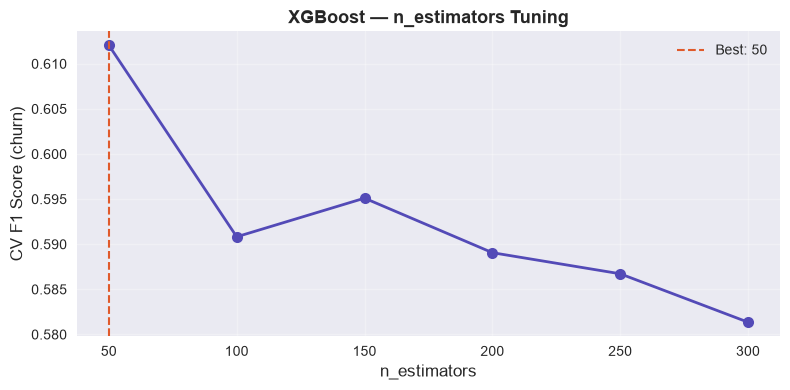

In [12]:
#  find best n_estimators
# n_estimators = how many trees XGBoost builds
# More trees = better learning but risk of overfitting

from sklearn.model_selection import cross_val_score

n_estimator_range = [50, 100, 150, 200, 250, 300]
f1_scores = []

print("Testing n_estimators:")
print(f"{'n_estimators':>14} {'CV F1 Mean':>12} {'CV F1 Std':>11}")
print("-" * 40)

for n in n_estimator_range:
    model = XGBClassifier(
        n_estimators     = n,
        scale_pos_weight = scale,
        random_state     = 42,
        eval_metric      = 'logloss',
        verbosity        = 0
    )
    # 5-fold cross validation on training data
    cv_scores = cross_val_score(model, X_train_proc, y_train,
                                 cv=5, scoring='f1')
    f1_scores.append(cv_scores.mean())
    print(f"{n:>14} {cv_scores.mean():>12.4f} {cv_scores.std():>11.4f}")

best_n = n_estimator_range[np.argmax(f1_scores)]
print(f"\nBest n_estimators: {best_n} (CV F1: {max(f1_scores):.4f})")

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_estimator_range, f1_scores, 'o-',
        color='#534AB7', linewidth=2, markersize=8)
ax.axvline(x=best_n, color='#E05A2B', linestyle='--',
           linewidth=1.5, label=f'Best: {best_n}')
ax.set_xlabel('n_estimators', fontsize=12)
ax.set_ylabel('CV F1 Score (churn)', fontsize=12)
ax.set_title('XGBoost — n_estimators Tuning', fontweight='bold', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('reports/xgb_n_estimators_tuning.png', dpi=150, bbox_inches='tight')
plt.show()